# <font color="#418FDE" size="6.5" uppercase>**APIs and Simple Civil Engineering AI Workflows**</font>

>Last update: 20260423.
    
By the end of this Lecture, you will be able to:
- Use beginner-friendly Python workflows to call Google and OpenAI APIs for simple AI tasks. 
- Describe simple civil engineering applications of AI and machine learning using lightweight Python and TensorFlow workflows. 
- Build small proof-of-concept workflows that combine text, image, tabular, or API-based tools in practical civil engineering scenarios. 


## **1. Beginner API Workflows**

### **1.1. OpenAI API Access**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_01_01.jpg?v=1776986668" width="250">



>* Python scripts use APIs to automate AI.
>* Useful for drafting and summarising engineering text.

>* OpenAI fits repeatable Python workflows.
>* Consistent automation supports many engineering tasks.

>* Review outputs, manage costs, protect data.
>* Build reliable workflows with human responsibility.



In [1]:
#@title Python Code - OpenAI API Access

# This script shows simple OpenAI API access.
# It uses short civil engineering notes.
# It runs safely in Google Colab.

# pip install openai.
# How to Setup ChatGPT in 60 seconds: https://www.youtube.com/watch?v=1lO6IHslajM
# How to Get an OpenAI/ChatGPT API Key: https://www.youtube.com/watch?v=OB99E7Y1cMA 

# API Documentation: https://developers.openai.com/api/docs
# API Pricing: https://developers.openai.com/api/docs/pricing 

# Import small libraries for this example.
import os
import pandas as pd

from openai import OpenAI

# Print a short pricing guidance note.
print("Check OpenAI pricing, billing, and usage tiers online.")
print("Review official pages before using trial or paid access.")

# Create tiny civil engineering sample notes.
notes = []
notes.append("Bridge inspection note: minor cracking near joint, monitor weekly.")

notes.append("Pump station note: unusual vibration observed, schedule maintenance check.")

# Build a small input table.
df = pd.DataFrame({"inspection_note": notes})

# Read the allowed environment key safely.
# os.environ["OPENAI_API_KEY"] = "your_api_key_here"
api_key = os.getenv("OPENAI_API_KEY")

# Prepare a safe default output list.
outputs = []

# Handle the no key path gracefully.
if not api_key:
    outputs.append("No API key found, so no live model call was made.")

    outputs.append("Add OPENAI_API_KEY_LLF to use this workflow.")

# Run a simple API workflow when key exists.
if api_key:
    client = OpenAI(api_key=api_key)

    first_note = df.loc[0, "inspection_note"]
    prompt_text = (
        "Rewrite this civil engineering note in plain language "

        "as one short maintenance summary: " + first_note)

    # Call the model with a short instruction.
    response = client.responses.create(
        model="gpt-4.1-mini",

        input=prompt_text,
        max_output_tokens=80,)

    # Store one live output and one placeholder.
    outputs.append(response.output_text.strip())
    outputs.append("Second row left unchanged to keep cost low.")

# Add outputs to the table.
df["api_result"] = outputs

# Print a compact teaching summary.
print("Workflow: note text goes in, model text comes out.")
print("Rows in example table:", len(df))

print(df.to_string(index=False))

Check OpenAI pricing, billing, and usage tiers online.
Review official pages before using trial or paid access.
Workflow: note text goes in, model text comes out.
Rows in example table: 2
                                                           inspection_note                                                   api_result
        Bridge inspection note: minor cracking near joint, monitor weekly. Bridge has small cracks near the joint; check it every week.
Pump station note: unusual vibration observed, schedule maintenance check.                  Second row left unchanged to keep cost low.


### **1.2. Google API Access**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_01_02.jpg?v=1776986698" width="250">



>* Google APIs connect Python to cloud AI.
>* Students learn credentials, requests, responses, and checks.

>* Google APIs connect engineering data to AI.
>* Python automates simple civil engineering tasks.

>* Protect credentials and handle data responsibly.
>* Validate API outputs with engineering judgment.



In [2]:
#@title Python Code - Google API Access

# Beginner Gemini access for civil engineering students.
# This script shows a tiny text-only Gemini workflow.
# It runs safely in Google Colab.

# Install the current Gemini SDK if needed.
# !pip install -q google-genai

# Import simple libraries for this example.
import os
import time

from google import genai

# Print a short pricing reminder.
# print("Check Gemini pricing and billing at:")
# print("https://ai.google.dev/gemini-api/docs/pricing")

# print("https://cloud.google.com/billing/docs/how-to/billing-overview")

# Read a Gemini API key safely.
# Recommended environment variable:
# os.environ["GEMINI_API_KEY"] = "your_api_key_here"

api_key = os.getenv("GEMINI_API_KEY")

# Try Google Colab secrets if the environment variable is not set.
if not api_key:
    try:

        from google.colab import userdata

        api_key = userdata.get("GEMINI_API_KEY")
    except Exception:
        api_key = None

# Build tiny civil engineering text observations.
notes = [
    "Hairline cracks near the curb.",

    "Moisture staining under one joint.",
    "No exposed rebar was visible.",]

# Build a simple text prompt.
prompt = (
    "You are helping civil engineering students. "

    "Summarize these bridge inspection notes in one short sentence. "
    "Then give one beginner-friendly next step. "
    "Keep the answer under 60 words. "

    "Notes: "
    + " ".join(notes))

# Show compact input.
print("\nInput notes:")
for note in notes:

    print("-", note)

print("\nPrompt:")
print(prompt)

# Skip the request if no key is available.
if not api_key:
    print("\nNo GEMINI_API_KEY found, so the request step is skipped.")

    print("Output example: Gemini would summarize the notes and suggest a next step.")

else:
    # Create the Gemini client.
    client = genai.Client(api_key=api_key)

    # Choose a current Gemini model.
    model_id = "gemini-3-flash-preview"

    # Send the text-only request.
    response = None
    start_time = time.time()

    try:
        print("\nTrying model:", model_id)

        response = client.models.generate_content(
            model=model_id,
            contents=prompt,)

    except Exception as error:
        print("\nRequest failed, so no model output.")
        print("Error preview:", str(error)[:300])

    elapsed = round(time.time() - start_time, 2)

    # Show output if the request worked.
    if response is not None:
        gemini_text = getattr(response, "text", None)

        if not gemini_text:
            gemini_text = "No text returned."

        print("\nGemini response:")
        print(gemini_text)

        # Show simple request metadata.
        print("\nRequest metadata:")
        print("Model:", model_id)

        print("Seconds:", elapsed)
        print("Status: success")

        # Show token metadata if available.
        usage = getattr(response, "usage_metadata", None)

        if usage:
            print("\nUsage metadata:")
            print(usage)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.



Input notes:
- Hairline cracks near the curb.
- Moisture staining under one joint.
- No exposed rebar was visible.

Prompt:
You are helping civil engineering students. Summarize these bridge inspection notes in one short sentence. Then give one beginner-friendly next step. Keep the answer under 60 words. Notes: Hairline cracks near the curb. Moisture staining under one joint. No exposed rebar was visible.

Trying model: gemini-3-flash-preview

Gemini response:
The bridge shows minor hairline cracking and moisture infiltration at a joint, but no rebar corrosion. 

**Next step:** Inspect the expansion joint seals for leaks to prevent water from damaging the underlying substructure.

Request metadata:
Model: gemini-3-flash-preview
Seconds: 4.79
Status: success

Usage metadata:
cache_tokens_details=None cached_content_token_count=None candidates_token_count=42 candidates_tokens_details=None prompt_token_count=59 prompt_tokens_details=[ModalityTokenCount(
  modality=<MediaModality.TEXT: 'T

### **1.3. API Workflow Comparison**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_01_03.jpg?v=1776986728" width="250">



>* Both APIs follow a similar basic workflow.
>* Main differences are setup and service details.

>* Python connects local engineering data to APIs.
>* Choose workflows by task fit and simplicity.

>* Compare reliability, cost, and data responsibility.
>* Choose testable, transparent workflows for growth.



In [3]:
#@title Python Code - API Workflow Comparison

# Compare two beginner API workflows.
# Use one civil engineering text task.
# Keep outputs short and readable.

# Install current SDKs if needed.
# !pip install -q openai google-genai pandas

# Import small required libraries.
import os
import time

import pandas as pd

from openai import OpenAI
from google import genai

# Store one tiny engineering note.
inspection_note = (
    "Bridge inspection note: minor cracking near joint, "

    "light rust on railing, drainage blocked by debris.")

# Build one shared prompt text.
prompt_text = (
    "You are helping civil engineering students. "

    "Summarize this inspection note in plain language. "
    "Then give one short maintenance recommendation. "
    "Keep the answer under 60 words. "

    "Note: " + inspection_note)

# Read available API credentials safely.
# Recommended environment variables:
# os.environ["OPENAI_API_KEY"] = "your_openai_key_here"

# os.environ["GEMINI_API_KEY"] = "your_gemini_key_here"

openai_key = os.getenv("OPENAI_API_KEY")
gemini_key = os.getenv("GEMINI_API_KEY")

# Try Google Colab secrets if environment variables are not set.
try:
    from google.colab import userdata

    if not openai_key:
        openai_key = userdata.get("OPENAI_API_KEY")

    if not gemini_key:
        gemini_key = userdata.get("GEMINI_API_KEY")

except Exception:
    pass

# Prepare default fallback messages.
openai_result = "No OPENAI_API_KEY found, so the OpenAI request was skipped."
gemini_result = "No GEMINI_API_KEY found, so the Gemini request was skipped."

openai_model_used = "not run"
gemini_model_used = "not run"

openai_seconds = None
gemini_seconds = None

# Try a simple OpenAI workflow.
if openai_key:
    openai_models = [

        "gpt-5.2",
        "gpt-5-mini",
        "gpt-4o-mini",]

    openai_errors = []

    for model_id in openai_models:
        try:
            print("Trying OpenAI model:", model_id)

            start_time = time.time()

            client = OpenAI(api_key=openai_key)

            response = client.responses.create(
                model=model_id,
                input=prompt_text,)

            openai_seconds = round(time.time() - start_time, 2)
            openai_result = response.output_text.strip()
            openai_model_used = model_id

            break

        except Exception as error:
            openai_errors.append(str(error)[:120])
            openai_result = "OpenAI request issue: " + str(error)[:120]

# Try a simple Gemini workflow.
if gemini_key:
    gemini_models = [

        "gemini-3-flash-preview",
        "gemini-2.5-flash",
        "gemini-2.5-flash-lite",]

    gemini_errors = []

    for model_id in gemini_models:
        try:
            print("Trying Gemini model:", model_id)

            start_time = time.time()

            client = genai.Client(api_key=gemini_key)

            response = client.models.generate_content(
                model=model_id,
                contents=prompt_text,)

            gemini_seconds = round(time.time() - start_time, 2)

            gemini_text = getattr(response, "text", None)

            if gemini_text:
                gemini_result = gemini_text.strip()
            else:

                gemini_result = "Gemini response returned no text."

            gemini_model_used = model_id

            break

        except Exception as error:
            gemini_errors.append(str(error)[:120])
            gemini_result = "Gemini request issue: " + str(error)[:120]

# Build a side by side comparison table.
results = pd.DataFrame({
        "Provider": ["OpenAI", "Google Gemini"],

        "Workflow step": ["SDK request", "SDK request"],
        "Model used": [openai_model_used, gemini_model_used],
        "Seconds": [openai_seconds, gemini_seconds],

        "Result": [openai_result, gemini_result],})

# Print a short teaching summary.
print("\nTask: summarize one bridge inspection note.")
print("OpenAI key found:", bool(openai_key))

print("Gemini key found:", bool(gemini_key))

print("\nInput note:")
print(inspection_note)

print("\nAPI workflow comparison:")
print(results.to_string(index=False, max_colwidth=70))

print("\nReminder: check official provider documentation for current access, pricing, and model options.")

Trying OpenAI model: gpt-5.2


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Trying Gemini model: gemini-3-flash-preview

Task: summarize one bridge inspection note.
OpenAI key found: True
Gemini key found: True

Input note:
Bridge inspection note: minor cracking near joint, light rust on railing, drainage blocked by debris.

API workflow comparison:
     Provider Workflow step             Model used  Seconds                                                                 Result
       OpenAI   SDK request                gpt-5.2     1.72 The bridge has small cracks near a joint, some light rust on the ra...
Google Gemini   SDK request gemini-3-flash-preview     3.61 The bridge has small cracks near the joints, light surface rust on ...

Reminder: check official provider documentation for current access, pricing, and model options.


## **2. Simple CE AI Workflows**

### **2.1. Inspection Text Classification**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_02_01.jpg?v=1776986762" width="250">



>* Inspection notes can be classified automatically.
>* Simple tools standardize records and support decisions.

>* Labeled comments train simple inspection classifiers.
>* Models find defect patterns for faster review.

>* Supports decisions, not engineering judgment replacement.
>* Organizes notes for trends, triage, planning.



TensorFlow version: 2.21.0
GPU available: False
Training samples: 20 Validation samples: 5
Final validation accuracy: 0.4
Macro precision: 0.167
Macro recall: 0.4 Macro F1: 0.233


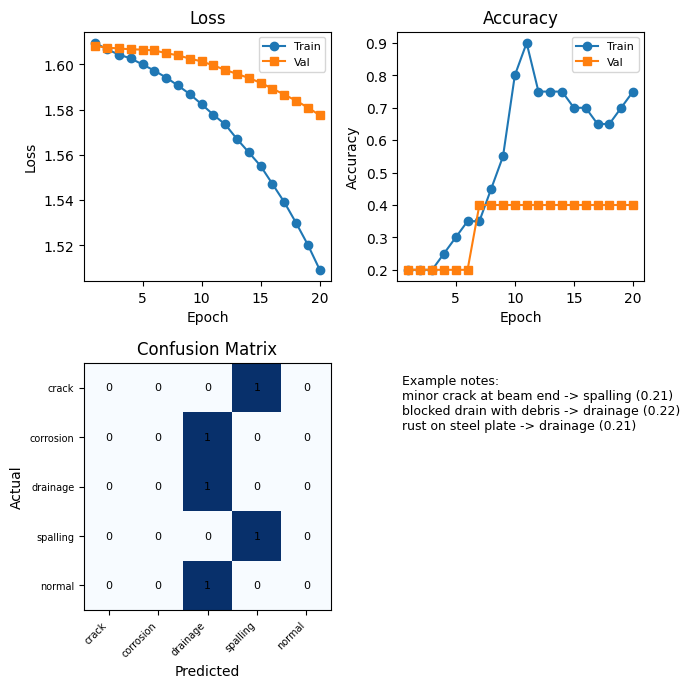

In [4]:
#@title Python Code - Inspection Text Classification

# Small workflow for inspection text classification.
# TensorFlow learns simple defect note patterns.
# Results support beginner civil engineering practice.

# Import quiet libraries for clean output.
import os
import warnings

import random

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import TensorFlow and helper metrics.
import tensorflow as tf
from sklearn.metrics import confusion_matrix, precision_score

from sklearn.metrics import recall_score, f1_score

tf.get_logger().setLevel("ERROR")

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Show framework version briefly.
print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

# Build a tiny labeled dataset.
texts = [
    "hairline crack along concrete beam",

    "longitudinal cracking near deck joint",
    "map cracking visible on wall surface",
    "minor crack at column base",

    "rust staining around steel connection",
    "severe corrosion at girder end",
    "section loss from corrosion on railing",

    "exposed reinforcement with rust marks",
    "drain blocked by sediment and leaves",
    "water not draining from inlet grate",

    "culvert shows debris blockage",
    "standing water near outlet channel",
    "spalling concrete under bridge soffit",

    "surface spall with loose concrete pieces",
    "small spalling near patch repair",
    "delaminated area with spall at edge",

    "no visible defect on inspected slab",
    "member appears sound and dry",
    "normal condition with no action needed",

    "inspection found no immediate defect",
    "fine crack around window opening",
    "corroded bolts with rust flakes",

    "catch basin blocked and overflowing",
    "spalled cover concrete at pier corner",
    "surface in good condition overall",]

# Define matching category labels.
labels_text = [
    "crack", "crack", "crack", "crack",

    "corrosion", "corrosion", "corrosion", "corrosion",
    "drainage", "drainage", "drainage", "drainage",
    "spalling", "spalling", "spalling", "spalling",

    "normal", "normal", "normal", "normal",
    "crack", "corrosion", "drainage", "spalling", "normal",]

# Store data in a small table.
df = pd.DataFrame({"text": texts, "label": labels_text})

class_names = ["crack", "corrosion", "drainage", "spalling", "normal"]

label_to_id = {
    "crack": 0,
    "corrosion": 1,

    "drainage": 2,
    "spalling": 3,
    "normal": 4,}

df["label_id"] = df["label"].map(label_to_id)

# Split data with simple index lists.
train_idx = [
    0, 1, 2, 4, 5, 6, 8, 9, 10, 12,

    13, 14, 16, 17, 18, 20, 21, 22, 23, 24,]

val_idx = [3, 7, 11, 15, 19]

train_texts = df.loc[train_idx, "text"].tolist()
train_labels = df.loc[train_idx, "label_id"].to_numpy()

val_texts = df.loc[val_idx, "text"].tolist()
val_labels = df.loc[val_idx, "label_id"].to_numpy()

# Check basic dataset sizes safely.
if len(train_texts) < 10 or len(val_texts) < 5:
    raise ValueError("Dataset split is too small.")

# Create TensorFlow datasets.
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_texts, train_labels))

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_texts, val_labels))

train_ds = train_ds.shuffle(20, seed=7).batch(4)
val_ds = val_ds.batch(4)

# Vectorize words into integer sequences.
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=200,

    output_mode="int",
    output_sequence_length=8,)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_texts).batch(4))

# Build a small text classifier.
# Shape=() means each example is one string.
model = tf.keras.Sequential([

        tf.keras.Input(shape=(), dtype=tf.string),
        vectorizer,
        tf.keras.layers.Embedding(200, 16),

        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(len(class_names), activation="softmax"),])

# Compile the model simply.
model.compile(
    optimizer="adam",

    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],)

# Train quietly for a few epochs.
history = model.fit(
    train_ds,

    validation_data=val_ds,
    epochs=20,
    verbose=0,)

# Predict validation classes.
probs = model.predict(val_ds, verbose=0)
pred_labels = np.argmax(probs, axis=1)

# Compute compact evaluation metrics.
cm = confusion_matrix(
    val_labels,

    pred_labels,
    labels=[0, 1, 2, 3, 4],)

precision = precision_score(
    val_labels,
    pred_labels,

    average="macro",
    zero_division=0,)

recall = recall_score(
    val_labels,
    pred_labels,

    average="macro",
    zero_division=0,)

f1 = f1_score(
    val_labels,
    pred_labels,

    average="macro",
    zero_division=0,)

# Print a short summary only.
print("Training samples:", len(train_texts), "Validation samples:", len(val_texts))
print("Final validation accuracy:", round(history.history["val_accuracy"][-1], 3))

print("Macro precision:", round(precision, 3))
print("Macro recall:", round(recall, 3), "Macro F1:", round(f1, 3))

# Create a safe helper for single-note predictions.
def predict_note(note):
    note_tensor = tf.constant([note])

    note_probs = model(note_tensor, training=False).numpy()
    note_id = int(np.argmax(note_probs, axis=1)[0])
    note_confidence = float(np.max(note_probs))

    return class_names[note_id], note_confidence

# Prepare one compact figure.
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
epochs = range(1, len(history.history["loss"]) + 1)

# Plot training and validation loss.
axes[0, 0].plot(epochs, history.history["loss"], marker="o")
axes[0, 0].plot(epochs, history.history["val_loss"], marker="s")

axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")

axes[0, 0].legend(["Train", "Val"], fontsize=8)

# Plot training and validation accuracy.
axes[0, 1].plot(epochs, history.history["accuracy"], marker="o")
axes[0, 1].plot(epochs, history.history["val_accuracy"], marker="s")

axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")

axes[0, 1].legend(["Train", "Val"], fontsize=8)

# Draw the confusion matrix.
im = axes[1, 0].imshow(cm, cmap="Blues")
axes[1, 0].set_title("Confusion Matrix")

axes[1, 0].set_xticks(range(len(class_names)))
axes[1, 0].set_yticks(range(len(class_names)))

axes[1, 0].set_xticklabels(
    class_names,
    rotation=45,

    ha="right",
    fontsize=7,)

axes[1, 0].set_yticklabels(class_names, fontsize=7)
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")

# Add matrix numbers clearly.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        axes[1, 0].text(
            j,
            i,

            str(cm[i, j]),
            ha="center",
            va="center",

            fontsize=8,)

# Show a few example predictions.
axes[1, 1].axis("off")

examples = [
    "minor crack at beam end",
    "blocked drain with debris",

    "rust on steel plate",]

example_text = "Example notes:\n"

for note in examples:
    label, confidence = predict_note(note)
    example_text += note + " -> " + label

    example_text += " (" + str(round(confidence, 2)) + ")\n"

axes[1, 1].text(
    0.02,
    0.95,

    example_text,
    va="top",
    fontsize=9,)

# Finish the compact layout.
plt.tight_layout()
plt.show()

### **2.2. Concrete Condition Prediction**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_02_02.jpg?v=1776986810" width="250">



>* Concrete data can support simple predictions.
>* Students learn pattern-based engineering decision support.

>* Tabular data predicts concrete condition outcomes.
>* Compare TensorFlow predictions with engineering judgment.

>* Models support decisions, not replace inspections.
>* Useful for screening, with engineering oversight.



### **2.3. Image Screening Workflow**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_02_03.jpg?v=1776986851" width="250">



>* AI screens inspection images for possible defects.
>* It prioritizes review, not final decisions.

>* Small labeled datasets enable simple image screening.
>* Outputs prioritize inspections with contextual metadata.

>* Image screening assists, but needs human validation.
>* Simple models prioritize damage images for review.



TensorFlow 2.21.0 using CPU
Screening task: vehicle-like images flagged for review
Test accuracy: 0.848
Vehicle recall: 0.632
Confusion matrix: [[788, 48], [134, 230]]


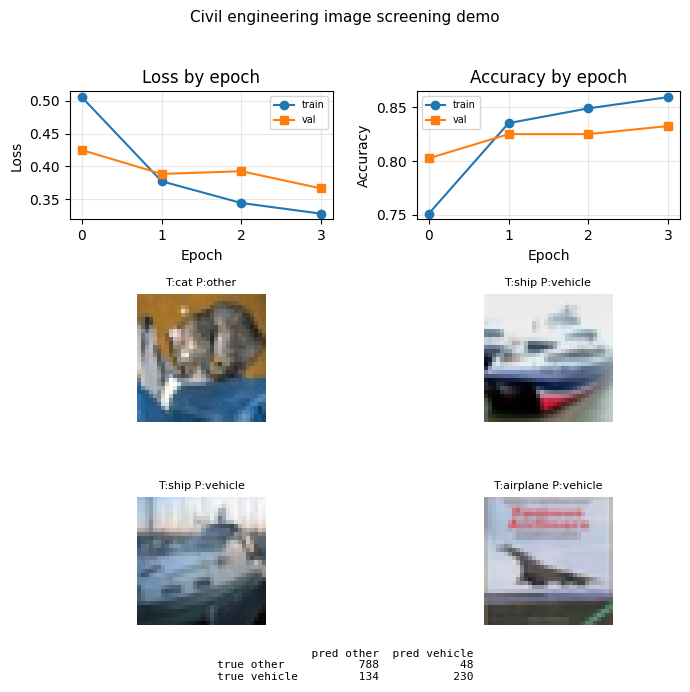

In [5]:
#@title Python Code - Image Screening Workflow

# Small image screening workflow example.
# TensorFlow helps sort inspection photos.
# CIFAR stands in for field images.

# Install only if TensorFlow missing.
# !pip install tensorflow==2.20.0

import os, warnings, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
import tensorflow as tf

from PIL import Image

tf.get_logger().setLevel("ERROR")
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show device and version.
device_name = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print("TensorFlow", tf.__version__, "using", device_name)

# Load CIFAR images quickly.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ["airplane", "automobile", "bird", "cat", "deer",

               "dog", "frog", "horse", "ship", "truck"]

# Create simple screening labels.
vehicle_ids = np.array([1, 8, 9])
y_train_bin = np.isin(y_train.flatten(), vehicle_ids).astype("float32")

y_test_bin = np.isin(y_test.flatten(), vehicle_ids).astype("float32")

# Keep a small teaching subset.
train_n = 6000
test_n = 1200

x_train = x_train[:train_n].astype("float32") / 255.0
x_test = x_test[:test_n].astype("float32") / 255.0

y_train_bin = y_train_bin[:train_n]
y_test_bin = y_test_bin[:test_n]
y_test_small = y_test[:test_n].flatten()

# Validate image shapes safely.
assert x_train.ndim == 4 and x_test.ndim == 4
assert x_train.shape[1:] == (32, 32, 3)

assert len(x_train) == len(y_train_bin)

# Build a small CNN model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),

    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")])

# Compile for binary screening.
model.compile(
    optimizer="adam",

    loss="binary_crossentropy",
    metrics=["accuracy"])

# Train quietly for a moment.
history = model.fit(
    x_train, y_train_bin,

    validation_split=0.2,
    epochs=4,
    batch_size=64,

    verbose=0)

# Predict screening probabilities.
probabilities = model.predict(x_test, verbose=0).flatten()
predicted_bin = (probabilities >= 0.5).astype("int32")

cm = confusion_matrix(y_test_bin.astype("int32"), predicted_bin)

# Summarize results briefly.
report = classification_report(
    y_test_bin.astype("int32"),

    predicted_bin,
    target_names=["other", "vehicle"],
    output_dict=True,

    zero_division=0)

# Print a short engineering message.
print("Screening task: vehicle-like images flagged for review")
print("Test accuracy:", round(report["accuracy"], 3))

print("Vehicle recall:", round(report["vehicle"]["recall"], 3))
print("Confusion matrix:", cm.tolist())

# Prepare compact teaching figure.
fig = plt.figure(figsize=(7, 7))
grid = fig.add_gridspec(3, 2)

ax1 = fig.add_subplot(grid[0, 0])
ax2 = fig.add_subplot(grid[0, 1])

# Show sample screening images.
for i in range(4):
    ax = fig.add_subplot(grid[1 + i // 2, i % 2])

    sample = (x_test[i] * 255).astype("uint8")
    sample = Image.fromarray(sample)
    ax.imshow(sample)

    true_name = class_names[y_test_small[i]]
    pred_name = "vehicle" if predicted_bin[i] == 1 else "other"

    ax.set_title(
        "T:" + true_name + " P:" + pred_name,
        fontsize=8)

    ax.axis("off")

# Plot loss history compactly.
ax1.plot(history.history["loss"], marker="o", label="train")
ax1.plot(history.history["val_loss"], marker="s", label="val")

ax1.set_title("Loss by epoch")
ax1.set_xlabel("Epoch")

ax1.set_ylabel("Loss")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot accuracy history compactly.
ax2.plot(history.history["accuracy"], marker="o", label="train")
ax2.plot(history.history["val_accuracy"], marker="s", label="val")

ax2.set_title("Accuracy by epoch")
ax2.set_xlabel("Epoch")

ax2.set_ylabel("Accuracy")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# Add confusion matrix inside figure.
cm_text = pd.DataFrame(
    cm,

    index=["true other", "true vehicle"],
    columns=["pred other", "pred vehicle"])
fig.suptitle("Civil engineering image screening demo", fontsize=11)

plt.figtext(
    0.5, 0.02,
    cm_text.to_string(),

    ha="center", va="bottom", family="monospace", fontsize=8)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

## **3. Beginner Workflow Integration**

### **3.1. NLP TensorFlow Pipeline**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_03_01.jpg?v=1776986897" width="250">



>* Text pipelines turn notes into categories.
>* Supports engineering triage with simple TensorFlow.

>* Text models combine easily with other data.
>* Language signals support broader engineering judgment.

>* Small, testable NLP supports engineering review.
>* Use prompts carefully; expand for broader decisions.



TensorFlow version: 2.21.0
GPU available: False

Preprocessing preview:
                                 original                                  cleaned   label
      Pothole growing near bus stop lane.       pothole growing near bus stop lane pothole
  Deep pothole reported after heavy rain.         deep pothole reported heavy rain pothole
 Road surface has several potholes today.      road surface several potholes today pothole
Crew noted pothole beside crosswalk area. crew noted pothole beside crosswalk area pothole

Prediction summary:
                             cleaned_note true_label predicted  confidence
 crew noted pothole beside crosswalk area    pothole   pothole        0.26
   water ponding shows poor drainage flow   drainage   pothole        0.26
      reflective sign panel cracked faded    signage   pothole        0.26
surface crack network widening near joint   cracking   pothole        0.26

Confusion matrix:
          cracking  drainage  pothole  signage
cracking   

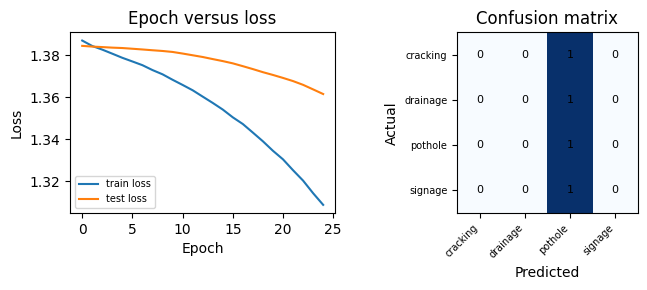

In [6]:
#@title Python Code - NLP TensorFlow Pipeline

# Small NLP workflow for civil notes.
# TensorFlow classifies simple inspection comments.
# Beginner steps stay compact and visible.

# pip install -q nltk

import os
import warnings
import random

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from nltk.tokenize import TreebankWordTokenizer
from nltk.corpus import stopwords

# Download only the small stopword list.
nltk.download("stopwords", quiet=True)

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

tf.get_logger().setLevel("ERROR")

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

# Build a tiny civil text dataset.
texts = [
    "Pothole growing near bus stop lane.",

    "Deep pothole reported after heavy rain.",
    "Road surface has several potholes today.",
    "Crew noted pothole beside crosswalk area.",

    "Drain inlet blocked by leaves and sediment.",
    "Standing water suggests drainage blockage.",
    "Storm drain clogged near curb opening.",

    "Water ponding shows poor drainage flow.",
    "Warning sign bent and partially missing.",
    "Traffic sign damaged after minor collision.",

    "Loose signpost leaning toward sidewalk edge.",
    "Reflective sign panel cracked and faded.",
    "Long crack visible along pavement shoulder.",

    "Pavement cracking spreading near wheel path.",
    "Inspector saw transverse cracks in asphalt.",
    "Surface crack network widening near joint.",]

labels = [
    "pothole", "pothole", "pothole", "pothole",
    "drainage", "drainage", "drainage", "drainage",

    "signage", "signage", "signage", "signage",
    "cracking", "cracking", "cracking", "cracking",]

# Clean text with simple NLTK steps.
tokenizer = TreebankWordTokenizer()
stop_words = set(stopwords.words("english"))

clean_texts = []

for text in texts:
    tokens = tokenizer.tokenize(text.lower())
    kept = []

    for token in tokens:
        if token.isalpha() and token not in stop_words:
            kept.append(token)

    clean_texts.append(" ".join(kept))

# Show a small preprocessing preview.
preview = pd.DataFrame({
        "original": texts[:4],

        "cleaned": clean_texts[:4],
        "label": labels[:4],})

print("\nPreprocessing preview:")
print(preview.to_string(index=False))

# Encode labels for TensorFlow.
label_names = sorted(list(set(labels)))

label_to_id = {}

for i in range(len(label_names)):
    label_to_id[label_names[i]] = i

y = []

for item in labels:
    y.append(label_to_id[item])

y = np.array(y, dtype=np.int32)

# Split data into train and test parts.
train_idx = np.array([0, 1, 4, 5, 8, 9, 12, 13, 2, 6, 10, 14])
test_idx = np.array([3, 7, 11, 15])

x_train_text = [clean_texts[i] for i in train_idx]
x_test_text = [clean_texts[i] for i in test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

# Create TensorFlow string datasets.
train_ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(x_train_text, dtype=tf.string),

        tf.constant(y_train, dtype=tf.int32),))

test_ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(x_test_text, dtype=tf.string),
        tf.constant(y_test, dtype=tf.int32),))

train_ds = train_ds.shuffle(12, seed=7).batch(4)
test_ds = test_ds.batch(4)

# Vectorize text into integer sequences.
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=100,

    output_mode="int",
    output_sequence_length=6,)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        tf.constant(x_train_text, dtype=tf.string)

    ).batch(4))

# Build a tiny text classification model.
# Each input example is one string, so shape=() is safest.
model = tf.keras.Sequential([

        tf.keras.Input(shape=(), dtype=tf.string),
        vectorizer,
        tf.keras.layers.Embedding(input_dim=100, output_dim=8),

        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(12, activation="relu"),
        tf.keras.layers.Dense(len(label_names), activation="softmax"),])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"],)

# Train quietly for a few epochs.
history = model.fit(
    train_ds,

    epochs=25,
    validation_data=test_ds,
    verbose=0,)

# Predict on the test notes.
probs = model.predict(test_ds, verbose=0)
pred_ids = np.argmax(probs, axis=1)

pred_labels = []

for item in pred_ids:
    pred_labels.append(label_names[int(item)])

true_labels = []

for item in y_test:
    true_labels.append(label_names[int(item)])

# Build a compact prediction summary.
summary = pd.DataFrame({
        "cleaned_note": x_test_text,

        "true_label": true_labels,
        "predicted": pred_labels,
        "confidence": np.round(np.max(probs, axis=1), 2),})

print("\nPrediction summary:")
print(summary.to_string(index=False))

# Compute a small confusion matrix.
cm = confusion_matrix(
    y_test,

    pred_ids,
    labels=list(range(len(label_names))),)

cm_df = pd.DataFrame(
    cm,
    index=label_names,

    columns=label_names,)

print("\nConfusion matrix:")
print(cm_df.to_string())

# Create a safe helper for new predictions.
def predict_note(note):
    clean_note_tokens = tokenizer.tokenize(note.lower())

    kept = []

    for token in clean_note_tokens:
        if token.isalpha() and token not in stop_words:
            kept.append(token)

    clean_note = " ".join(kept)

    note_tensor = tf.constant([clean_note], dtype=tf.string)
    note_probs = model(note_tensor, training=False).numpy()

    predicted_id = int(np.argmax(note_probs, axis=1)[0])
    confidence = float(np.max(note_probs))

    return clean_note, label_names[predicted_id], confidence

# Print a few new examples.
new_examples = [
    "large pothole beside travel lane",

    "storm drain blocked with sediment",
    "bent traffic sign near sidewalk",
    "long pavement crack near joint",]

example_rows = []

for note in new_examples:
    clean_note, predicted_label, confidence = predict_note(note)

    example_rows.append([
            note,
            clean_note,

            predicted_label,
            round(confidence, 2),])

example_df = pd.DataFrame(
    example_rows,
    columns=["new_note", "cleaned", "predicted", "confidence"],)

print("\nNew note predictions:")
print(example_df.to_string(index=False))

# Plot loss and confusion matrix together.
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="test loss")

axes[0].set_title("Epoch versus loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[0].legend(fontsize=7)

axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion matrix")

axes[1].set_xticks(range(len(label_names)))
axes[1].set_yticks(range(len(label_names)))

axes[1].set_xticklabels(
    label_names,
    rotation=45,

    ha="right",
    fontsize=7,)

axes[1].set_yticklabels(label_names, fontsize=7)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(

            j,
            i,
            str(cm[i, j]),

            ha="center",
            va="center",
            fontsize=8,)

plt.tight_layout()
plt.show()

### **3.2. Local Model API**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_03_02.jpg?v=1776986936" width="250">



>* Local APIs connect programs to nearby models.
>* They combine engineering text and images.

>* Local APIs connect small practical workflow components.
>* They enable secure, flexible early experimentation.

>* Build reliable workflows, not perfect automation.
>* Combine mixed inputs into practical engineer-reviewed outputs.



TensorFlow version: 2.21.0
Predicted classes: major_damage, major_damage, major_damage
API explanation: It seems like "major_damage" was repeated. If you're referring to different classes of damage, each class typically signifies the severity of structural issues. Major damage indicates significant structural impairments that could compromise safety, requiring immediate attention and repairs.
                                      note predicted_class  confidence
     deck shows wide crack and rust stains    major_damage       0.872
ponding water remains around blocked drain    major_damage       0.747
 small crack visible but no loose concrete    major_damage       0.484


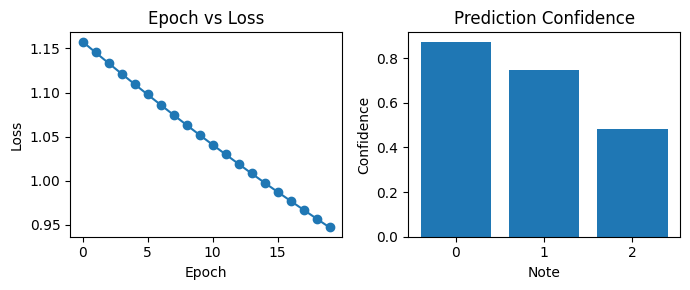

In [7]:
#@title Python Code - Local Model API

# Small local model meets one API.
# This example fits civil notes.
# Outputs stay compact and beginner friendly.

# pip install openai.

import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd, matplotlib.pyplot as plt

import tensorflow as tf
from openai import OpenAI
tf.get_logger().setLevel('ERROR')

random.seed(7); np.random.seed(7); tf.random.set_seed(7)

# Show TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)

# Build tiny training table.
notes = [
    'minor hairline crack on deck',

    'small surface crack near joint',
    'light cracking with no spalling',
    'fine crack and dry surface',

    'severe crack with exposed rebar',
    'major spalling and deep crack',
    'urgent section loss and corrosion',

    'wide crack with loose concrete',
    'standing water near drain inlet',
    'blocked culvert and ponding observed',

    'water overflow after rainfall',
    'drainage backup with debris',]

# Define simple target classes.
labels = [
    'minor_crack', 'minor_crack', 'minor_crack', 'minor_crack',

    'major_damage', 'major_damage', 'major_damage', 'major_damage',
    'drainage_issue', 'drainage_issue', 'drainage_issue', 'drainage_issue']
class_names = ['drainage_issue', 'major_damage', 'minor_crack']

label_map = {'drainage_issue': 0, 'major_damage': 1, 'minor_crack': 2}

# Convert labels into integers.
y = np.array([label_map[item] for item in labels], dtype='int32')

# Vectorize short inspection notes.
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=60, output_mode='tf_idf')

text_ds = tf.data.Dataset.from_tensor_slices(notes).batch(4)
vectorizer.adapt(text_ds)
X = vectorizer(np.array(notes)).numpy().astype('float32')

# Check small matrix shape.
if X.shape[0] != len(y):
    raise ValueError('Feature and label sizes differ.')

# Build a tiny local classifier.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],)),

    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')])
model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Train quietly for a few epochs.
history = model.fit(X, y, epochs=20, verbose=0)

# Prepare new field notes.
new_notes = [
    'deck shows wide crack and rust stains',

    'ponding water remains around blocked drain',
    'small crack visible but no loose concrete']
X_new = vectorizer(np.array(new_notes)).numpy().astype('float32')

probs = model.predict(X_new, verbose=0)
pred_ids = np.argmax(probs, axis=1)
pred_names = [class_names[int(i)] for i in pred_ids]

conf = np.max(probs, axis=1)

# Build a compact summary table.
summary = pd.DataFrame({
    'note': new_notes,

    'predicted_class': pred_names,
    'confidence': np.round(conf, 3)})

# Create one short API explanation.
key = os.getenv('OPENAI_API_KEY_LLF')
joined = ', '.join(pred_names)

api_text = 'API skipped: missing OPENAI_API_KEY_LLF.'

# Call the API only if available.
if key:
    client = OpenAI(api_key=key)

    prompt = (
        'Explain these inspection classes for a site engineer: '
        + joined

        + '. Use two short sentences.')
    try:
        response = client.responses.create(

            model='gpt-4o-mini',
            input=prompt)
        api_text = response.output_text.strip()

    except Exception:
        api_text = 'API call failed, so local results are shown only.'

# Print compact teaching outputs.
print('Predicted classes:', joined)
print('API explanation:', api_text)

print(summary.to_string(index=False))

# Plot loss and confidence together.
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].plot(history.history['loss'], marker='o')

axes[0].set_title('Epoch vs Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Show prediction confidence bars.
axes[1].bar(range(len(conf)), conf)
axes[1].set_title('Prediction Confidence')

axes[1].set_xlabel('Note')
axes[1].set_ylabel('Confidence')
plt.tight_layout()

plt.show()

### **3.3. Civil AI Mini Project**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_12/Lecture_B/image_03_03.jpg?v=1776986971" width="250">



>* Small workflows solve practical engineering problems.
>* Combining simple tools creates useful decisions.

>* Start narrow with clear, manageable outputs.
>* Combine mixed data for practical screening.

>* Integrated workflows support construction and asset decisions.
>* Learning comes from end-to-end data handling.



TensorFlow version: 2.21.0
GPU available: False
Overall note accuracy: 0.75
Priority counts: {'monitor': 6, 'review': 3, 'urgent': 3}

Compact project report:
   zone  rain_mm predicted_risk  risk_score priority
S1    A        2           high        0.60   review
S2    B       18           high        0.54   urgent
S3    B        4           high        0.69   review
S4    A        0            low        0.40  monitor
S5    C       12           high        0.52   urgent
S6    A        1            low        0.46  monitor

**Mini Report Summary:**

- **Urgent Sites:** 3 
- **Review Sites:** 3 
- **Key Concern:** Focus on wetter zones.


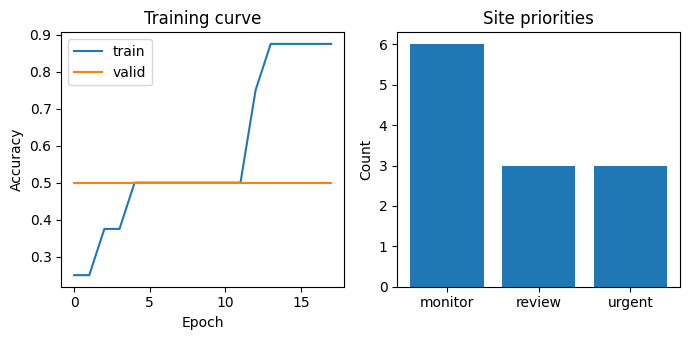

In [8]:
#@title Python Code - Civil AI Mini Project

# Small civil engineering workflow example.
# Inspection notes become simple risk labels.
# Results end in one compact report.

# Install packages if needed.
# !pip install -q nltk openai

# Import quiet base libraries first.
import os
import warnings

import random

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
import tensorflow as tf

from sklearn.metrics import accuracy_score
from nltk.tokenize import TreebankWordTokenizer

tf.get_logger().setLevel("ERROR")

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Show framework version briefly.
print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

# Build a tiny inspection dataset.
notes = [
    "minor hairline crack near curb no ponding",

    "standing water covers lane after light rain",
    "pothole growing quickly near bus stop",
    "drain grate clear and pavement looks stable",

    "shoulder erosion visible beside culvert outlet",
    "small surface crack but traffic flow normal",
    "blocked inlet causing water backup at corner",

    "fresh patch performing well no visible distress",
    "deep rutting and rough ride reported today",
    "joint seal intact and sidewalk remains level",

    "sediment buildup reduces ditch flow capacity",
    "bridge deck dry with only minor staining",]

# Create simple target labels.
labels_text = [
    "low", "high", "high", "low",

    "high", "low", "high", "low",
    "high", "low", "high", "low",]

# Add small tabular project details.
rain_mm = [2, 18, 4, 0, 12, 1, 20, 0, 3, 0, 15, 0]
zone = ["A", "B", "B", "A", "C", "A", "B", "A", "C", "A", "C", "B"]

site_df = pd.DataFrame({
        "note": notes,
        "rain_mm": rain_mm,

        "zone": zone,})

# Clean text with simple tokenization.
# TreebankWordTokenizer avoids needing the larger punkt resource.
tokenizer = TreebankWordTokenizer()

clean_notes = []

for text in site_df["note"]:
    tokens = tokenizer.tokenize(text.lower())
    words = []

    for token in tokens:
        if token.isalpha():
            words.append(token)

    clean_notes.append(" ".join(words))

# Encode labels for training.
label_map = {"low": 0, "high": 1}
id_to_label = {0: "low", 1: "high"}

y = np.array(
    [label_map[item] for item in labels_text],
    dtype=np.int32,)

site_df["clean_note"] = clean_notes
site_df["target"] = y

# Split tiny train and test sets.
train_text = clean_notes[:8]
test_text = clean_notes[8:]

y_train = y[:8]
y_test = y[8:]

# Create TensorFlow string datasets.
train_ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(train_text, dtype=tf.string),

        tf.constant(y_train, dtype=tf.int32),))

test_ds = tf.data.Dataset.from_tensor_slices((
        tf.constant(test_text, dtype=tf.string),
        tf.constant(y_test, dtype=tf.int32),))

train_ds = train_ds.shuffle(8, seed=7).batch(4)
test_ds = test_ds.batch(4)

# Vectorize text with TensorFlow tools.
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=100,

    output_mode="tf_idf",)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        tf.constant(train_text, dtype=tf.string)

    ).batch(4))

# Build a very small classifier.
# Each example is one string, so shape=() is safest.
model = tf.keras.Sequential([

        tf.keras.Input(shape=(), dtype=tf.string),
        vectorizer,
        tf.keras.layers.Dense(8, activation="relu"),

        tf.keras.layers.Dense(1, activation="sigmoid"),])

# Compile the small model.
model.compile(
    optimizer="adam",

    loss="binary_crossentropy",
    metrics=["accuracy"],)

# Train quietly for a few epochs.
history = model.fit(
    train_ds,

    epochs=18,
    verbose=0,
    validation_data=test_ds,)

# Predict risk on all notes.
all_notes_ds = tf.data.Dataset.from_tensor_slices(
    tf.constant(clean_notes, dtype=tf.string)

).batch(4)

prob = model.predict(all_notes_ds, verbose=0).flatten()
pred = (prob >= 0.5).astype(int)

site_df["predicted_risk"] = [
    id_to_label[int(v)] for v in pred]

site_df["risk_score"] = np.round(prob, 2)

# Add a simple priority rule.
priority = []

for i in range(len(site_df)):
    high_rain = site_df.loc[i, "rain_mm"] >= 10
    high_text = site_df.loc[i, "predicted_risk"] == "high"

    if high_rain and high_text:
        priority.append("urgent")
    elif high_rain or high_text:

        priority.append("review")
    else:
        priority.append("monitor")

site_df["priority"] = priority

# Measure compact model accuracy.
acc = accuracy_score(y, pred)

print("Overall note accuracy:", round(float(acc), 2))
print("Priority counts:", site_df["priority"].value_counts().to_dict())

# Build a compact results table.
report_df = site_df[
    ["zone", "rain_mm", "predicted_risk", "risk_score", "priority"]

].copy()

report_df.index = ["S" + str(i + 1) for i in range(len(report_df))]

print("\nCompact project report:")
print(report_df.head(6).to_string())

# Create a short local summary.
urgent_count = int((site_df["priority"] == "urgent").sum())
review_count = int((site_df["priority"] == "review").sum())

summary_text = (
    "Mini report: "
    + str(urgent_count)

    + " urgent sites, "
    + str(review_count)
    + " review sites. "

    + "Highest concern appears in wetter zones.")

# Optionally ask OpenAI for cleaner wording.
# Recommended environment variable:
# os.environ["OPENAI_API_KEY"] = "your_api_key_here"

api_key = os.getenv("OPENAI_API_KEY") or os.getenv("OPENAI_API_KEY_LLF")

# Try Google Colab secrets if environment variables are not set.
if not api_key:
    try:

        from google.colab import userdata

        api_key = userdata.get("OPENAI_API_KEY")
    except Exception:
        api_key = None

if api_key:
    try:
        from openai import OpenAI

        client = OpenAI(api_key=api_key)

        prompt = (
            "Rewrite this briefly for a civil engineer: "
            + summary_text)

        reply = client.responses.create(
            model="gpt-4o-mini",
            input=prompt,)

        summary_text = reply.output_text.strip()

    except Exception as error:
        print("OpenAI summary skipped:", str(error)[:120])

print("\n" + summary_text)

# Prepare one summary figure.
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="valid")

axes[0].set_title("Training curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

axes[0].legend()

counts = site_df["priority"].value_counts()

axes[1].bar(counts.index, counts.values)
axes[1].set_title("Site priorities")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**APIs and Simple Civil Engineering AI Workflows**</font>


In this lecture, you learned to:
- Use beginner-friendly Python workflows to call Google and OpenAI APIs for simple AI tasks. 
- Describe simple civil engineering applications of AI and machine learning using lightweight Python and TensorFlow workflows. 
- Build small proof-of-concept workflows that combine text, image, tabular, or API-based tools in practical civil engineering scenarios. 

In the next Module (Module 13), we will go over 'Trustworthy AI in CE'